In [1]:
!pip install -e .

Obtaining file:///home/pmourafr/projects/mlp/src
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ctscan-project (pyproject.toml) ... done
  Created wheel for ctscan-project: filename=ctscan_project-0.1.0-0.editable-py3-none-any.whl size=2793 sha256=b2f27fefb83a751b7c208b5c862bb6dcfc236f8f7d610ea78449c71973a05506
  Stored in directory: /tmp/pip-ephem-wheel-cache-phe4ute6/wheels/42/b5/a0/47d8b900cb32826da59020171b6aeaf7da0c3efdfea354c42c
Successfully built ctscan-project
  Attempting uninstall: ctscan-project
    Found existing installation: ctscan-project 0.1.0
    Uninstalling ctscan-project-0.1.0:
      Successfully uninstalled ctscan-project-0.1.0


In [5]:
!python --version

Python 3.13.7


In [6]:
DATA_FOLDER_PATH = "../data/CT_scan/LUNA"

# CT Scan data

## Data profile

In [36]:
!wc -l ../data/CT_scan/LUNA/annotations.csv

1187 ../data/CT_scan/LUNA/annotations.csv


In [39]:
 !head  ../data/CT_scan/LUNA/annotations.csv

seriesuid,coordX,coordY,coordZ,diameter_mm
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-128.6994211,-175.3192718,-298.3875064,5.651470635
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,103.7836509,-211.9251487,-227.12125,4.224708481
1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208,69.63901724,-140.9445859,876.3744957,5.786347814
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,-24.0138242,192.1024053,-391.0812764,8.143261683
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,2.441546798,172.4648812,-405.4937318,18.54514997
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,90.93171321,149.0272657,-426.5447146,18.20857028
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,89.54076865,196.4051593,-515.0733216,16.38127631
1.3.6.1.4.1.14519.5.2.1.6279.6001.100953483028192176989979435275,81.50964574,54.9572186,-150.3464233,10.36232088
1.3.6.1.4.1.14519.5.2.1.6279.6001.10268196240

In [44]:
 !head  ../data/CT_scan/LUNA/candidates.csv

seriesuid,coordX,coordY,coordZ,class
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-56.08,-67.85,-311.92,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,53.21,-244.41,-245.17,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,103.66,-121.8,-286.62,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-33.66,-72.75,-308.41,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-32.25,-85.36,-362.51,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-26.65,-203.07,-165.07,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-74.99,-114.79,-311.92,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-16.14,-248.61,-239.55,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,135.89,-141.41,-252.2,0


## Debug code

In [14]:
from CT_scan import LunaDataset
from CT_scan import dsets
from CT_scan import vis

import time
%matplotlib widget

In [9]:
candidateInfo_list = dsets.getCandidateInfoList(requireOnDisk_bool=False)

Reading ../data/CT_scan/LUNA/annotations.csv
Reading ../data/CT_scan/LUNA/candidates.csv


In [10]:
positiveInfo_list = [x for x in candidateInfo_list if x[0]]
diameter_list = [x[1] for x in positiveInfo_list]

In [11]:
for index in range(0, len(diameter_list), 100):
    print(f"{index:4}\t{diameter_list[index]:4.1f} mm")

   0	32.3 mm
 100	17.7 mm
 200	13.0 mm
 300	10.0 mm
 400	 8.2 mm
 500	 7.0 mm
 600	 6.3 mm
 700	 5.7 mm
 800	 5.1 mm
 900	 4.7 mm
1000	 4.0 mm
1100	 0.0 mm
1200	 0.0 mm
1300	 0.0 mm


In [12]:
positiveSample_list = vis.findPositiveSamples()

Reading ../data/CT_scan/LUNA/annotations.csv
Reading ../data/CT_scan/LUNA/candidates.csv
0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(47.90350511, 37.60442008, -99.93417567))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(44.19, 37.79, -107.01))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(40.69, 32.19, -97.15))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.44242293, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251347598519939390311', center_xy

../data/CT_scan/LUNA/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.183982839679953938397312236359.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.183982839679953938397312236359 0 False [0, 1, 2, 3, 4, 5, 6]


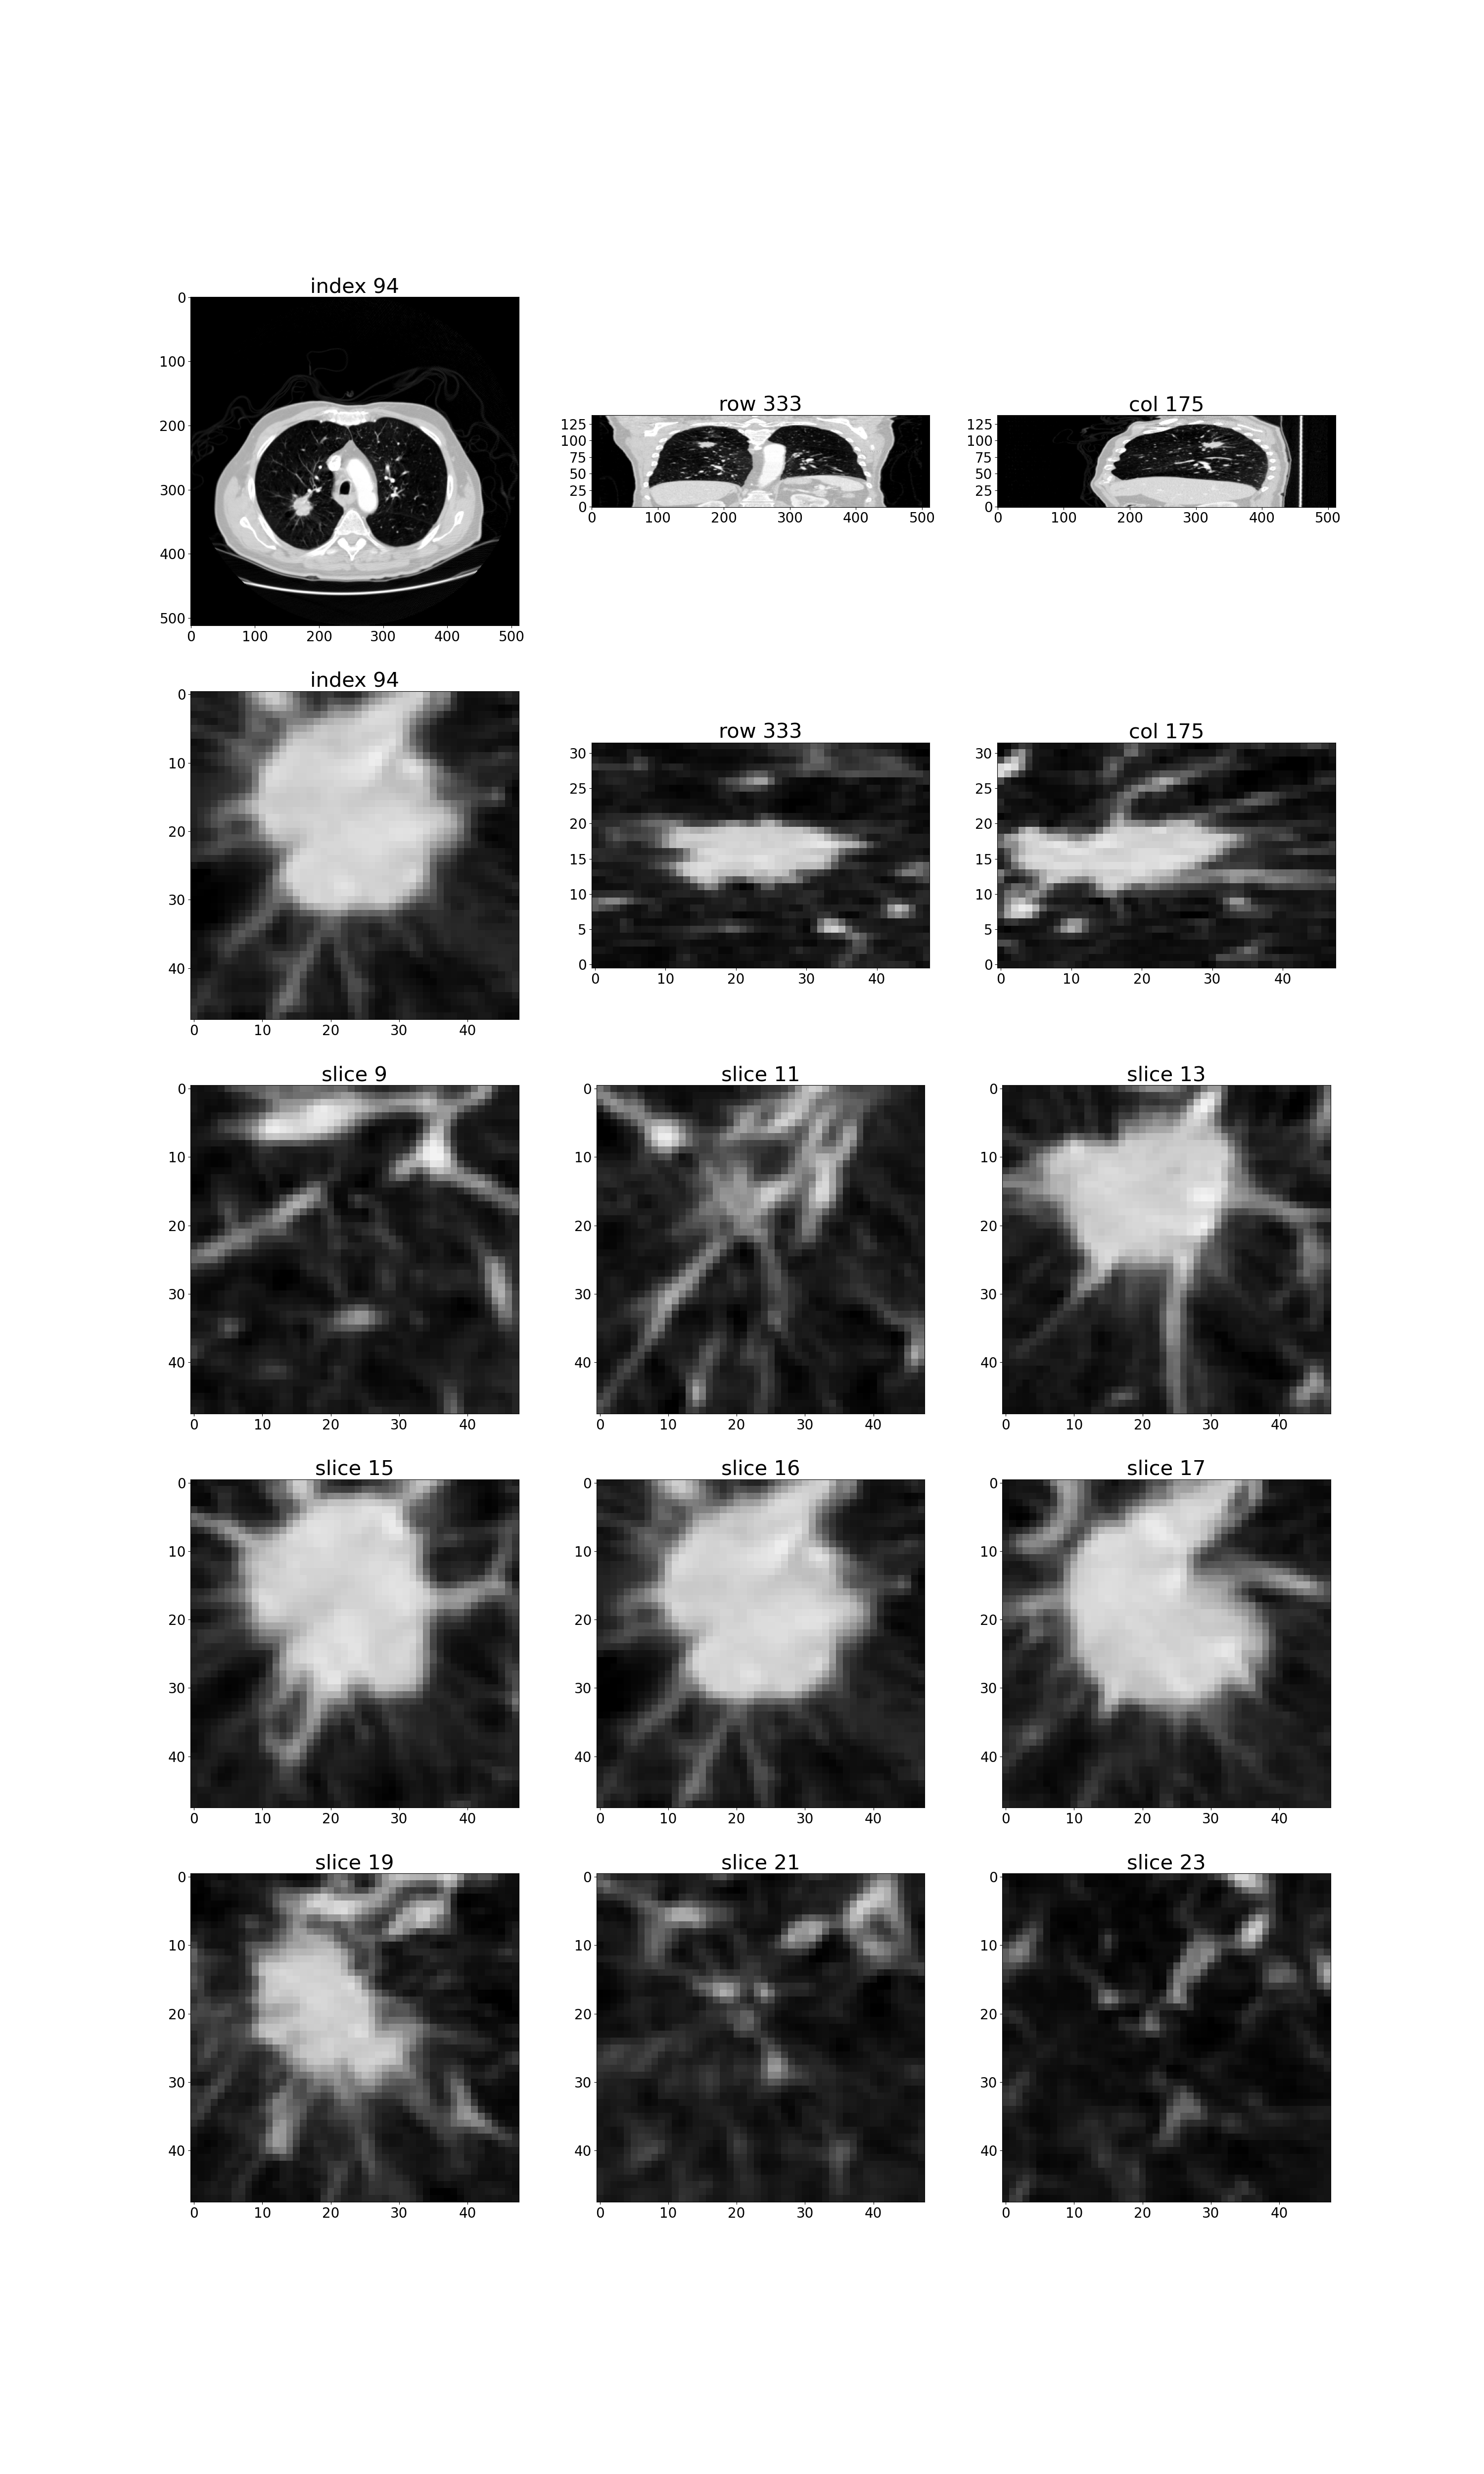

In [15]:
series_uid = positiveSample_list[11][2]
vis.showCandidate(series_uid)

# Exercise

 Implement a program that iterates through a LunaDataset instance, and time
 how long it takes to do so. In the interest of time, it might make sense to have
 an option to limit the iterations to the first N=1000 samples.
 * How long does it take to run the first time? - 152 s
 * How long does it take to run the second time?
 * What does clearing the cache do to the runtime?
 * What does using the last N=1000 samples do to the first/second runtime

In [ ]:
dataset = LunaDataset.LunaDataset()
N = 1000

In [23]:
start = time.time()
for index in range(N):
    dataset[index]
    
end = time.time()
print(f"{end - start} seconds")

series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886'
../data/CT_scan/LUNA/subset1/1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886.mhd
series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800'
../data/CT_scan/LUNA/subset5/1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800.mhd
series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251347598519939390311'
../data/CT_scan/LUNA/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251347598519939390311.mhd
series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.481278873893653517789960724156'
../data/CT_scan/LUNA/subset3/1.3.6.1.4.1.14519.5.2.1.6279.6001.481278873893653517789960724156.mhd
series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.487268565754493433372433148666'
../data/CT_scan/LUNA/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.487268565754493433372433148666.mhd
series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.177086402277715068525592995222'
../data/CT_scan/LUNA/subset8/1

In [1]:
import torch

In [15]:
x = torch.randn(2, 3, 4)
print(x.shape)

x = x.view(x.size(0), -1)
print(x.shape)

x = torch.randn(2, 3, 4)
flatter = torch.nn.Flatten()
x = flatter(x)
print(x.shape)


torch.Size([2, 3, 4])
torch.Size([2, 12])
torch.Size([2, 12])


# Runnig model

In [4]:
!pwd


/home/pmourafr/projects/mlp/src


In [6]:
!python CT_scan/training.py

Traceback (most recent call last):
  File "/home/pmourafr/projects/mlp/src/CT_scan/training.py", line 5, in <module>
    from .LunaTrainingApp import LunaTrainigApp
ImportError: attempted relative import with no known parent package
